# TODOs
- Need to implement TensorRT for model acceleration

2026-05-15 15:14:57.406177581 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


Device target: raspi
Using model: /home/nvidia/Desktop/realsense_n_lidar/models/yolo11n.tflite
Task frame: camera-origin frame: X=forward, Y=left, Z=up
Camera pitch down: 45.0 deg
Camera origin is fixed at: [0.0, 0.0, 0.0] mm
Robot base in task frame (fixed absolute): [100.0, 0.0, -600.0] mm
Loaded onnx detector from: /home/nvidia/Desktop/realsense_n_lidar/models/yolo11n.onnx
Loaded cached RGB-D from: /home/nvidia/Desktop/realsense_n_lidar/captures_3d
Point cloud in task frame: X(forward)=[233.6, 971.7]mm, Z(up)=[-846.0, -381.1]mm

Detected objects in task frame (X=forward, Y=left, Z=up):
1. bottle score=0.85, bbox=(237, 240, 297, 387), center_mm=(349.0, 50.4, -459.2), size_mm=(89.0, 44.9, 128.2), seg_px=6882
2. keyboard score=0.79, bbox=(445, 186, 580, 422), center_mm=(383.6, -205.8, -529.8), size_mm=(125.7, 136.3, 135.6), seg_px=20512
3. bottle score=0.67, bbox=(422, 1, 464, 80), center_mm=(946.8, -203.6, -483.4), size_mm=(124.7, 49.3, 73.9), seg_px=2075
4. cup score=0.48, bbox=(244,

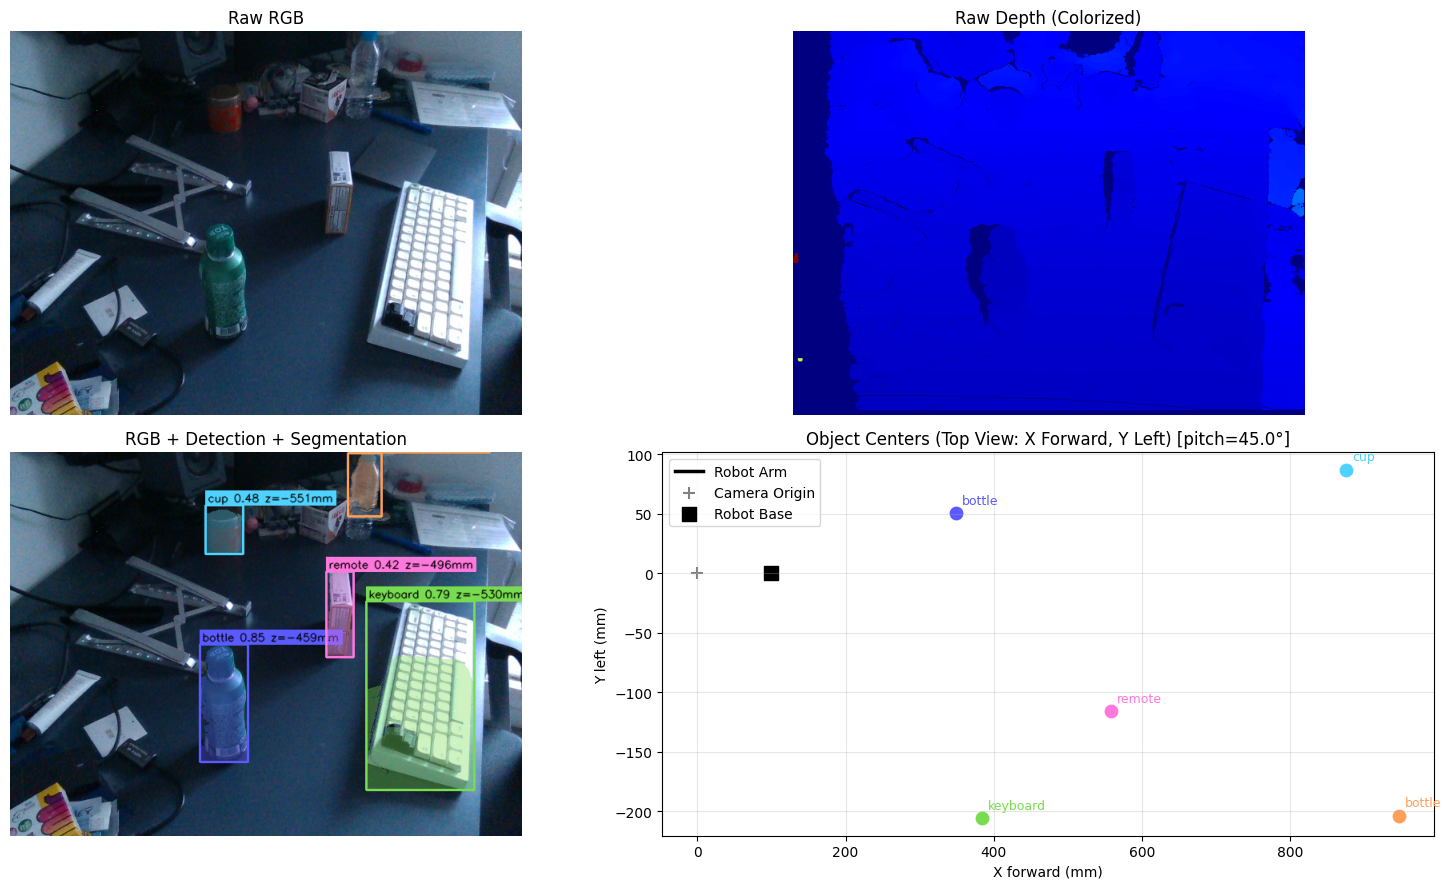

In [1]:
import json
from pathlib import Path
from types import SimpleNamespace

import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
try:
    import pyrealsense2 as rs
    RS_IMPORT_ERROR = None
except Exception as e:
    rs = None
    RS_IMPORT_ERROR = e

from robot_arm_servo_model import HOME_DEG, fk_servo

# Set this to either 'raspi' or 'jetson_orin_nx'.
DEVICE_TARGET = "raspi"

if DEVICE_TARGET not in {"raspi", "jetson_orin_nx"}:
    raise ValueError("DEVICE_TARGET must be 'raspi' or 'jetson_orin_nx'")

TASK_FRAME_NAME = "camera-origin frame: X=forward, Y=left, Z=up"
CAMERA_ORIGIN_MM = np.array([0.0, 0.0, 0.0], dtype=np.float32)

# Camera pitch: positive = camera tilted nose-down (looking downward)
# e.g. 45.0 means the camera optical axis points 45° below horizontal
CAMERA_PITCH_DOWN_DEG = 45.0


def camera_to_task_frame(points_mm: np.ndarray) -> np.ndarray:
    """Convert raw RealSense camera frame (x=right, y=down, z=forward) to
    task frame (X=forward, Y=left, Z=up), accounting for camera pitch.

    With pitch angle θ (camera tilted nose-down around camera X / world Y axis):
      X_task =  cos(θ)·z_cam - sin(θ)·y_cam
      Y_task = -x_cam
      Z_task = -cos(θ)·y_cam - sin(θ)·z_cam
    At θ=0 this reduces to [z, -x, -y].
    """
    pts = np.asarray(points_mm, dtype=np.float32)
    if pts.size == 0:
        return pts.copy()
    was_1d = pts.ndim == 1
    pts_2d = np.atleast_2d(pts)
    pitch = float(np.deg2rad(CAMERA_PITCH_DOWN_DEG))
    s, c = float(np.sin(pitch)), float(np.cos(pitch))
    x_task = c * pts_2d[:, 2] - s * pts_2d[:, 1]
    y_task = -pts_2d[:, 0]
    z_task = -c * pts_2d[:, 1] - s * pts_2d[:, 2]
    transformed = np.stack([x_task, y_task, z_task], axis=1)
    return transformed[0] if was_1d else transformed


def size_camera_to_task_frame(size_mm: np.ndarray) -> np.ndarray:
    size = np.asarray(size_mm, dtype=np.float32)
    return np.abs(np.array([size[2], size[0], size[1]], dtype=np.float32))


# ============================================================================
# Robot base is defined directly in task/world frame (camera-origin frame).
# This keeps absolute base coordinates unchanged when CAMERA_PITCH_DOWN_DEG changes.
# task frame: X=forward, Y=left, Z=up
# ============================================================================
ROBOT_BASE_MM = np.array([100.0, 0.0, -600.0], dtype=np.float32)

BASE_DIR = Path.cwd()
CACHE_DIR = BASE_DIR / "captures_3d"
CACHE_RGB_PATH = CACHE_DIR / "cached_rgb.png"
CACHE_DEPTH_PATH = CACHE_DIR / "cached_depth.npy"
CACHE_INTRINSICS_PATH = CACHE_DIR / "cached_intrinsics.json"
USE_SAVED_RGBD_IF_AVAILABLE = True
SAVE_CAPTURED_RGBD = True

MODEL_PATHS = {
    "raspi": BASE_DIR / "models" / "yolo11n.tflite",
    "jetson_orin_nx": BASE_DIR / "models" / "yolo11n.onnx",
}
MODEL_PATH = MODEL_PATHS[DEVICE_TARGET]

try:
    from tflite_runtime.interpreter import Interpreter
except Exception:
    Interpreter = None

try:
    import onnxruntime as ort
except Exception:
    ort = None

try:
    import plotly.graph_objects as go
except Exception:
    go = None

COCO80_NAMES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard",
    "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard",
    "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase",
    "scissors", "teddy bear", "hair drier", "toothbrush",
]

VIS_PALETTE_BGR = [
    (255, 90, 90),
    (80, 220, 120),
    (90, 160, 255),
    (255, 210, 80),
    (220, 120, 255),
]


class BaseYoloDetector:
    def __init__(self, model_path: Path, input_size: int = 640, conf_th: float = 0.25, nms_th: float = 0.45):
        if not model_path.exists():
            raise FileNotFoundError(f"Model not found: {model_path}")
        self.model_path = model_path
        self.input_size = input_size
        self.conf_th = conf_th
        self.nms_th = nms_th

    def _letterbox(self, image: np.ndarray) -> tuple[np.ndarray, float, int, int]:
        h, w = image.shape[:2]
        scale = min(self.input_size / w, self.input_size / h)
        nw = int(round(w * scale))
        nh = int(round(h * scale))
        px = (self.input_size - nw) // 2
        py = (self.input_size - nh) // 2
        resized = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
        canvas = np.full((self.input_size, self.input_size, 3), 114, dtype=np.uint8)
        canvas[py : py + nh, px : px + nw] = resized
        return canvas, scale, px, py

    def _prepare_input(self, image: np.ndarray) -> tuple[np.ndarray, float, int, int]:
        letterboxed, scale, px, py = self._letterbox(image)
        rgb = cv2.cvtColor(letterboxed, cv2.COLOR_BGR2RGB)
        input_tensor = rgb.transpose(2, 0, 1)[None].astype(np.float32) / 255.0
        return input_tensor, scale, px, py

    def _normalize_predictions(self, predictions: np.ndarray) -> np.ndarray:
        arr = np.array(predictions)
        if arr.ndim == 3:
            arr = arr[0]
        if arr.ndim == 2 and arr.shape[0] < arr.shape[1]:
            arr = arr.T
        return arr

    def _postprocess(self, image: np.ndarray, preds: np.ndarray, scale: float, px: int, py: int) -> list[dict]:
        h, w = image.shape[:2]
        boxes, scores, class_ids = [], [], []

        for row in preds:
            if row.shape[0] < 6:
                continue

            cx, cy, bw, bh = row[:4]
            objectness = float(row[4])
            class_scores = row[5:]
            if class_scores.size == 0:
                continue

            class_id = int(np.argmax(class_scores))
            class_conf = float(class_scores[class_id])
            score = objectness * class_conf
            if score < self.conf_th:
                continue

            x1 = int((cx - bw / 2 - px) / scale)
            y1 = int((cy - bh / 2 - py) / scale)
            x2 = int((cx + bw / 2 - px) / scale)
            y2 = int((cy + bh / 2 - py) / scale)

            x1 = max(0, min(w - 1, x1))
            y1 = max(0, min(h - 1, y1))
            x2 = max(0, min(w - 1, x2))
            y2 = max(0, min(h - 1, y2))
            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2 - x1, y2 - y1])
            scores.append(score)
            class_ids.append(class_id)

        if not boxes:
            return []

        kept = cv2.dnn.NMSBoxes(boxes, scores, self.conf_th, self.nms_th)
        if len(kept) == 0:
            return []

        detections = []
        for idx in np.array(kept).reshape(-1):
            x, y, bw, bh = boxes[int(idx)]
            class_id = class_ids[int(idx)]
            detections.append(
                {
                    "bbox": (x, y, x + bw, y + bh),
                    "score": float(scores[int(idx)]),
                    "class_id": class_id,
                    "class_name": COCO80_NAMES[class_id] if class_id < len(COCO80_NAMES) else str(class_id),
                }
            )
        return detections

    def infer(self, input_tensor: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def detect(self, image: np.ndarray) -> list[dict]:
        input_tensor, scale, px, py = self._prepare_input(image)
        raw = self.infer(input_tensor)
        preds = self._normalize_predictions(raw)
        return self._postprocess(image, preds, scale, px, py)


class TFLiteYoloDetector(BaseYoloDetector):
    def __init__(self, model_path: Path, input_size: int = 640, conf_th: float = 0.25, nms_th: float = 0.45):
        super().__init__(model_path, input_size, conf_th, nms_th)
        if Interpreter is None:
            raise RuntimeError("tflite_runtime is not installed in this environment.")
        try:
            self.interpreter = Interpreter(model_path=str(model_path))
        except Exception as e:
            size_bytes = model_path.stat().st_size if model_path.exists() else -1
            raise RuntimeError(f"Failed to load TFLite model: {model_path} (size={size_bytes} bytes). {e}") from e
        self.interpreter.allocate_tensors()
        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

    def infer(self, input_tensor: np.ndarray) -> np.ndarray:
        self.interpreter.set_tensor(self.input_details[0]["index"], input_tensor)
        self.interpreter.invoke()
        return self.interpreter.get_tensor(self.output_details[0]["index"])


class ONNXYoloDetector(BaseYoloDetector):
    def __init__(self, model_path: Path, input_size: int = 640, conf_th: float = 0.25, nms_th: float = 0.45):
        super().__init__(model_path, input_size, conf_th, nms_th)
        if ort is None:
            raise RuntimeError("onnxruntime is not installed in this environment.")
        self.session = ort.InferenceSession(str(model_path), providers=["CPUExecutionProvider"])
        self.input_name = self.session.get_inputs()[0].name

    def infer(self, input_tensor: np.ndarray) -> np.ndarray:
        outputs = self.session.run(None, {self.input_name: input_tensor})[0]
        arr = np.array(outputs)
        if arr.ndim == 3:
            arr = arr[0]
        if arr.ndim == 2 and arr.shape[0] < arr.shape[1]:
            arr = arr.T

        if arr.shape[1] == 84:
            objectness = np.ones((arr.shape[0], 1), dtype=arr.dtype)
            arr = np.concatenate([arr[:, :4], objectness, arr[:, 4:]], axis=1)
        return arr


def build_detector(device_target: str, model_path: Path) -> BaseYoloDetector:
    # Prefer model based on DEVICE_TARGET, then fallback to the other model if load fails.
    if device_target == "raspi":
        primary = ("tflite", model_path)
        fallback = ("onnx", MODEL_PATHS["jetson_orin_nx"])
    else:
        primary = ("onnx", model_path)
        fallback = ("tflite", MODEL_PATHS["raspi"])

    errors = []
    for fmt, path in (primary, fallback):
        if not path.exists():
            errors.append(f"{fmt} missing: {path}")
            continue
        try:
            if fmt == "tflite":
                detector = TFLiteYoloDetector(path)
            else:
                detector = ONNXYoloDetector(path)
            print(f"Loaded {fmt} detector from: {path}")
            return detector
        except Exception as e:
            errors.append(f"{fmt} load failed ({path}): {e}")

    raise RuntimeError("Could not initialize detector. Details: " + " | ".join(errors))


def estimate_3d_box(depth_image: np.ndarray, intrinsics, bbox: tuple[int, int, int, int]) -> dict | None:
    h, w = depth_image.shape[:2]
    x1, y1, x2, y2 = bbox
    x1 = max(0, min(w - 1, int(x1)))
    y1 = max(0, min(h - 1, int(y1)))
    x2 = max(0, min(w, int(x2)))
    y2 = max(0, min(h, int(y2)))
    if x2 - x1 < 6 or y2 - y1 < 6:
        return None

    roi = depth_image[y1:y2, x1:x2]
    valid = roi[roi > 0]
    if valid.size < 20:
        return None

    anchor_depth = int(np.percentile(valid, 40))
    band_mm = max(80, int(anchor_depth * 0.12))
    points_mm = []

    step = max(2, min((x2 - x1) // 24 + 1, (y2 - y1) // 24 + 1))
    for py in range(y1, y2, step):
        for px in range(x1, x2, step):
            depth_mm = int(depth_image[py, px])
            if depth_mm <= 0 or abs(depth_mm - anchor_depth) > band_mm:
                continue
            z_m = depth_mm / 1000.0
            x_m = (float(px) - intrinsics.ppx) / intrinsics.fx * z_m
            y_m = (float(py) - intrinsics.ppy) / intrinsics.fy * z_m
            points_mm.append([x_m * 1000.0, y_m * 1000.0, z_m * 1000.0])

    if len(points_mm) < 12:
        return None

    points_mm = np.asarray(points_mm, dtype=np.float32)
    min_xyz = np.percentile(points_mm, 5, axis=0)
    max_xyz = np.percentile(points_mm, 95, axis=0)
    center_xyz = (min_xyz + max_xyz) / 2.0
    size_xyz = max_xyz - min_xyz
    return {
        "min_xyz_mm": min_xyz,
        "max_xyz_mm": max_xyz,
        "center_xyz_mm": center_xyz,
        "size_xyz_mm": size_xyz,
        "anchor_depth_mm": anchor_depth,
        "band_mm": band_mm,
    }


def depth_segmentation_mask(depth_image: np.ndarray, bbox: tuple[int, int, int, int], anchor_depth_mm: int, band_mm: int) -> np.ndarray:
    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(depth_image.shape[1], x2)
    y2 = min(depth_image.shape[0], y2)

    mask = np.zeros(depth_image.shape[:2], dtype=bool)
    roi = depth_image[y1:y2, x1:x2]
    local_mask = (roi > 0) & (np.abs(roi.astype(np.int32) - int(anchor_depth_mm)) <= int(band_mm))
    mask[y1:y2, x1:x2] = local_mask
    return mask


def sample_raw_point_cloud(
    depth_image: np.ndarray,
    color_image: np.ndarray,
    intrinsics,
    step: int = 4,
    max_points: int = 14000,
    min_depth_mm: float = 120.0,
    max_depth_mm: float = 3000.0,
    trim_low_pct: float = 1.0,
    trim_high_pct: float = 99.0,
):
    ys = np.arange(0, depth_image.shape[0], step)
    xs = np.arange(0, depth_image.shape[1], step)
    grid_x, grid_y = np.meshgrid(xs, ys)

    d_mm = depth_image[grid_y, grid_x].astype(np.float32)
    valid = (d_mm >= min_depth_mm) & (d_mm <= max_depth_mm)
    if not np.any(valid):
        return np.zeros((0, 3), dtype=np.float32), np.zeros((0, 3), dtype=np.float32)

    u = grid_x[valid].astype(np.float32)
    v = grid_y[valid].astype(np.float32)
    z_m = d_mm[valid] / 1000.0

    x_m = (u - intrinsics.ppx) / intrinsics.fx * z_m
    y_m = (v - intrinsics.ppy) / intrinsics.fy * z_m

    xyz_mm = np.stack([x_m * 1000.0, y_m * 1000.0, z_m * 1000.0], axis=1).astype(np.float32)

    rgb = color_image[grid_y[valid], grid_x[valid]][:, ::-1].astype(np.float32) / 255.0

    if xyz_mm.shape[0] > 20:
        z = xyz_mm[:, 2]
        z_low = np.percentile(z, trim_low_pct)
        z_high = np.percentile(z, trim_high_pct)
        keep = (z >= z_low) & (z <= z_high)
        xyz_mm = xyz_mm[keep]
        rgb = rgb[keep]

    if xyz_mm.shape[0] > max_points:
        idx = np.random.choice(xyz_mm.shape[0], size=max_points, replace=False)
        xyz_mm = xyz_mm[idx]
        rgb = rgb[idx]

    return xyz_mm, rgb


def overlay_masks(image_bgr: np.ndarray, items: list[dict]) -> np.ndarray:
    out = image_bgr.copy()
    alpha = 0.35

    for i, item in enumerate(items):
        color = item.get("color_bgr", VIS_PALETTE_BGR[i % len(VIS_PALETTE_BGR)])
        x1, y1, x2, y2 = item["bbox"]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)

        if item.get("seg_mask") is not None:
            mask = item["seg_mask"]
            color_layer = np.zeros_like(out, dtype=np.uint8)
            color_layer[:, :] = color
            out = np.where(mask[..., None], (out * (1 - alpha) + color_layer * alpha).astype(np.uint8), out)

        label = f"{item['class_name']} {item['score']:.2f}"
        center = item.get("center_xyz_mm")
        if center is not None:
            label += f" z={center[2]:.0f}mm"

        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(out, (x1, max(0, y1 - th - 8)), (x1 + tw + 6, y1), color, -1)
        cv2.putText(out, label, (x1 + 3, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)

    return out


def intrinsics_to_dict(intrinsics) -> dict:
    return {
        "width": int(intrinsics.width),
        "height": int(intrinsics.height),
        "ppx": float(intrinsics.ppx),
        "ppy": float(intrinsics.ppy),
        "fx": float(intrinsics.fx),
        "fy": float(intrinsics.fy),
    }


def intrinsics_from_dict(data: dict, width: int = 640, height: int = 480):
    return SimpleNamespace(
        width=int(data.get("width", width)),
        height=int(data.get("height", height)),
        ppx=float(data["ppx"]),
        ppy=float(data["ppy"]),
        fx=float(data["fx"]),
        fy=float(data["fy"]),
    )


def load_cached_rgbd():
    color_image = cv2.imread(str(CACHE_RGB_PATH), cv2.IMREAD_COLOR)
    if color_image is None:
        raise RuntimeError(f"Failed to read cached RGB image: {CACHE_RGB_PATH}")
    depth_image = np.load(CACHE_DEPTH_PATH).astype(np.uint16)
    with open(CACHE_INTRINSICS_PATH, "r", encoding="utf-8") as f:
        intrinsics = intrinsics_from_dict(
            json.load(f),
            width=int(color_image.shape[1]),
            height=int(color_image.shape[0]),
        )
    return color_image, depth_image, intrinsics


def save_cached_rgbd(color_image: np.ndarray, depth_image: np.ndarray, intrinsics) -> None:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(CACHE_RGB_PATH), color_image):
        raise RuntimeError(f"Failed to save cached RGB image: {CACHE_RGB_PATH}")
    np.save(CACHE_DEPTH_PATH, depth_image.astype(np.uint16))
    with open(CACHE_INTRINSICS_PATH, "w", encoding="utf-8") as f:
        json.dump(intrinsics_to_dict(intrinsics), f, indent=2)


print(f"Device target: {DEVICE_TARGET}")
print(f"Using model: {MODEL_PATH}")
print(f"Task frame: {TASK_FRAME_NAME}")
print(f"Camera pitch down: {CAMERA_PITCH_DOWN_DEG} deg")
print(f"Camera origin is fixed at: {CAMERA_ORIGIN_MM.tolist()} mm")
print(f"Robot base in task frame (fixed absolute): {ROBOT_BASE_MM.tolist()} mm")
detector = build_detector(DEVICE_TARGET, MODEL_PATH)

cache_available = CACHE_RGB_PATH.exists() and CACHE_DEPTH_PATH.exists() and CACHE_INTRINSICS_PATH.exists()
if USE_SAVED_RGBD_IF_AVAILABLE and cache_available:
    color_image, depth_image, intrinsics = load_cached_rgbd()
    print(f"Loaded cached RGB-D from: {CACHE_DIR}")
else:
    if rs is None:
        raise RuntimeError(
            "Live RealSense capture requires a working pyrealsense2 install. "
            f"Import error: {RS_IMPORT_ERROR}"
        )
    pipeline = rs.pipeline()
    config = rs.config()
    config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
    config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
    align = rs.align(rs.stream.color)

    pipeline.start(config)
    try:
        for _ in range(20):
            pipeline.wait_for_frames()

        frames = align.process(pipeline.wait_for_frames())
        depth_frame = frames.get_depth_frame()
        color_frame = frames.get_color_frame()
        if not depth_frame or not color_frame:
            raise RuntimeError("Could not get synchronized RGB-D frame from RealSense.")

        depth_image = np.asanyarray(depth_frame.get_data())
        color_image = np.asanyarray(color_frame.get_data())
        intrinsics = depth_frame.profile.as_video_stream_profile().intrinsics
    finally:
        pipeline.stop()

    if SAVE_CAPTURED_RGBD:
        save_cached_rgbd(color_image, depth_image, intrinsics)
        print(f"Saved cached RGB-D to: {CACHE_DIR}")

detections = detector.detect(color_image)
scene_objects = []
for i, det in enumerate(detections):
    cuboid = estimate_3d_box(depth_image, intrinsics, det["bbox"])
    color_bgr = VIS_PALETTE_BGR[i % len(VIS_PALETTE_BGR)]
    color_rgb = (color_bgr[2] / 255.0, color_bgr[1] / 255.0, color_bgr[0] / 255.0)
    if cuboid is None:
        seg_mask = None
        center_xyz = None
        size_xyz = None
        center_camera_xyz = None
        size_camera_xyz = None
        seg_area = 0
    else:
        seg_mask = depth_segmentation_mask(depth_image, det["bbox"], cuboid["anchor_depth_mm"], cuboid["band_mm"])
        center_camera_xyz = cuboid["center_xyz_mm"]
        size_camera_xyz = cuboid["size_xyz_mm"]
        center_xyz = camera_to_task_frame(center_camera_xyz)
        size_xyz = size_camera_to_task_frame(size_camera_xyz)
        seg_area = int(np.count_nonzero(seg_mask))

    scene_objects.append(
        {
            "class_name": det["class_name"],
            "score": float(det["score"]),
            "bbox": tuple(int(v) for v in det["bbox"]),
            "center_xyz_mm": center_xyz,
            "size_xyz_mm": size_xyz,
            "center_camera_xyz_mm": center_camera_xyz,
            "size_camera_xyz_mm": size_camera_xyz,
            "seg_mask": seg_mask,
            "seg_area_px": seg_area,
            "color_bgr": color_bgr,
            "color_rgb_norm": color_rgb,
        }
    )

scene_objects = sorted(scene_objects, key=lambda x: x["score"], reverse=True)
annotated = overlay_masks(color_image, scene_objects)
depth_vis = cv2.applyColorMap(cv2.convertScaleAbs(depth_image, alpha=0.03), cv2.COLORMAP_JET)

point_cloud_camera_xyz_mm, point_cloud_rgb = sample_raw_point_cloud(
    depth_image,
    color_image,
    intrinsics,
    step=4,
    max_points=14000,
    min_depth_mm=120.0,
    max_depth_mm=1000.0,
)
point_cloud_xyz_mm = camera_to_task_frame(point_cloud_camera_xyz_mm)
arm_points_m, arm_fingers_m = fk_servo(HOME_DEG, ROBOT_BASE_MM)
arm_points_mm = arm_points_m * 1000.0
arm_fingers_mm = arm_fingers_m * 1000.0

if point_cloud_xyz_mm.shape[0] > 0:
    forward = point_cloud_xyz_mm[:, 0]
    height = point_cloud_xyz_mm[:, 2]
    print(
        f"Point cloud in task frame: X(forward)=[{forward.min():.1f}, {forward.max():.1f}]mm, "
        f"Z(up)=[{height.min():.1f}, {height.max():.1f}]mm"
    )

print("\nDetected objects in task frame (X=forward, Y=left, Z=up):")
if not scene_objects:
    print("- No object detected.")
else:
    for i, item in enumerate(scene_objects, start=1):
        center = item["center_xyz_mm"]
        size = item["size_xyz_mm"]
        if center is None:
            print(f"{i}. {item['class_name']} score={item['score']:.2f}, bbox={item['bbox']}, 3D unavailable")
        else:
            print(
                f"{i}. {item['class_name']} score={item['score']:.2f}, bbox={item['bbox']}, "
                f"center_mm=({center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f}), "
                f"size_mm=({size[0]:.1f}, {size[1]:.1f}, {size[2]:.1f}), seg_px={item['seg_area_px']}"
            )

fig = plt.figure(figsize=(16, 9))
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_title("Raw RGB")
ax1.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
ax1.axis("off")

ax2 = fig.add_subplot(2, 2, 2)
ax2.set_title("Raw Depth (Colorized)")
ax2.imshow(cv2.cvtColor(depth_vis, cv2.COLOR_BGR2RGB))
ax2.axis("off")

ax3 = fig.add_subplot(2, 2, 3)
ax3.set_title("RGB + Detection + Segmentation")
ax3.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
ax3.axis("off")

ax4 = fig.add_subplot(2, 2, 4)
ax4.set_title(f"Object Centers (Top View: X Forward, Y Left) [pitch={CAMERA_PITCH_DOWN_DEG}°]")
ax4.set_xlabel("X forward (mm)")
ax4.set_ylabel("Y left (mm)")
for item in scene_objects:
    center = item["center_xyz_mm"]
    if center is None:
        continue
    color = item.get("color_rgb_norm", (1.0, 0.0, 0.0))
    ax4.scatter(center[0], center[1], s=80, c=[color])
    ax4.text(center[0] + 8, center[1] + 8, item["class_name"], fontsize=9, color=color)
ax4.plot(arm_points_mm[:, 0], arm_points_mm[:, 1], color="black", linewidth=2.5, label="Robot Arm")
ax4.scatter(arm_points_mm[:, 0], arm_points_mm[:, 1], s=30, c="black")
ax4.scatter(CAMERA_ORIGIN_MM[0], CAMERA_ORIGIN_MM[1], s=80, c="gray", marker="+", label="Camera Origin")
ax4.scatter(ROBOT_BASE_MM[0], ROBOT_BASE_MM[1], s=100, c="black", marker="s", label="Robot Base")
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

ENABLE_INTERACTIVE_3D = True
SAVE_ROTATION_GIF = False
ROTATION_GIF_PATH = BASE_DIR / "captures_3d" / "pointcloud_rotate.gif"
ROTATION_FRAMES = 72

if ENABLE_INTERACTIVE_3D:
    if go is None:
        print("Interactive 3D skipped: plotly is not installed.")
    else:
        traces = []
        if point_cloud_xyz_mm.shape[0] > 0:
            traces.append(
                go.Scatter3d(
                    x=point_cloud_xyz_mm[:, 0],
                    y=point_cloud_xyz_mm[:, 1],
                    z=point_cloud_xyz_mm[:, 2],
                    mode="markers",
                    marker={
                        "size": 1,
                        "color": point_cloud_rgb,
                        "opacity": 0.6,
                    },
                    name="raw cloud",
                )
            )

        traces.append(
            go.Scatter3d(
                x=[float(CAMERA_ORIGIN_MM[0])],
                y=[float(CAMERA_ORIGIN_MM[1])],
                z=[float(CAMERA_ORIGIN_MM[2])],
                mode="markers+text",
                marker={"size": 7, "color": "gray", "symbol": "cross"},
                text=["Camera Origin (0,0,0)"],
                textposition="top center",
                name="Camera Origin",
            )
        )

        traces.append(
            go.Scatter3d(
                x=arm_points_mm[:, 0],
                y=arm_points_mm[:, 1],
                z=arm_points_mm[:, 2],
                mode="lines+markers+text",
                line={"width": 5, "color": "rgb(80,130,255)"},
                marker={"size": 4, "color": "rgb(80,130,255)"},
                text=["base", "j1", "j2", "j3", "tool base", "tcp"],
                textposition="top center",
                name="Robot Arm Home",
            )
        )

        traces.append(
            go.Scatter3d(
                x=arm_fingers_mm[:, 0],
                y=arm_fingers_mm[:, 1],
                z=arm_fingers_mm[:, 2],
                mode="lines+markers",
                line={"width": 8, "color": "rgb(220,120,40)"},
                marker={"size": 3, "color": "rgb(220,120,40)"},
                name="Gripper Width",
            )
        )

        for obj_idx, item in enumerate(scene_objects):
            center = item["center_xyz_mm"]
            if center is None:
                continue
            color = item.get("color_rgb_norm", (1.0, 0.0, 0.0))
            legend_label = f"[{obj_idx}] {item['class_name']}"
            traces.append(
                go.Scatter3d(
                    x=[float(center[0])],
                    y=[float(center[1])],
                    z=[float(center[2])],
                    mode="markers+text",
                    marker={"size": 6, "color": f"rgb({int(color[0] * 255)},{int(color[1] * 255)},{int(color[2] * 255)})"},
                    text=[legend_label],
                    textposition="top center",
                    name=legend_label,
                )
            )

        fig_interactive = go.Figure(data=traces)
        fig_interactive.update_layout(
            title=f"Interactive 3D Point Cloud + Virtual Robot Arm + Camera Origin (pitch={CAMERA_PITCH_DOWN_DEG}° down)",
            scene={
                "xaxis_title": "X (forward, mm)",
                "yaxis_title": "Y (left, mm)",
                "zaxis_title": "Z (up, mm)",
            },
            height=700,
        )
        fig_interactive.show()

if SAVE_ROTATION_GIF:
    ROTATION_GIF_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig_rot = plt.figure(figsize=(8, 8))
    ax_rot = fig_rot.add_subplot(111, projection="3d")
    ax_rot.set_title("Raw Point Cloud + Detected Object Centers + Robot Arm")

    if point_cloud_xyz_mm.shape[0] > 0:
        ax_rot.scatter(
            point_cloud_xyz_mm[:, 0],
            point_cloud_xyz_mm[:, 1],
            point_cloud_xyz_mm[:, 2],
            c=point_cloud_rgb,
            s=1,
            alpha=0.5,
        )

    ax_rot.plot(arm_points_mm[:, 0], arm_points_mm[:, 1], arm_points_mm[:, 2], color="tab:blue", linewidth=2.5)
    ax_rot.scatter(arm_points_mm[:, 0], arm_points_mm[:, 1], arm_points_mm[:, 2], c="tab:blue", s=30)
    ax_rot.plot(arm_fingers_mm[:, 0], arm_fingers_mm[:, 1], arm_fingers_mm[:, 2], color="tab:orange", linewidth=3.0)

    ax_rot.scatter(
        CAMERA_ORIGIN_MM[0],
        CAMERA_ORIGIN_MM[1],
        CAMERA_ORIGIN_MM[2],
        c=[(0.5, 0.5, 0.5)],
        s=80,
        marker="+",
    )
    ax_rot.text(CAMERA_ORIGIN_MM[0], CAMERA_ORIGIN_MM[1], CAMERA_ORIGIN_MM[2], "Camera Origin", color="gray")

    for item in scene_objects:
        center = item["center_xyz_mm"]
        if center is None:
            continue
        color = item.get("color_rgb_norm", (1.0, 0.0, 0.0))
        ax_rot.scatter(center[0], center[1], center[2], c=[color], s=90, marker="x")
        ax_rot.text(center[0], center[1], center[2], item["class_name"], color=color)

    ax_rot.set_xlabel("X forward (mm)")
    ax_rot.set_ylabel("Y left (mm)")
    ax_rot.set_zlabel("Z up (mm)")

    def _update_view(frame_idx: int):
        azim = (frame_idx * 360.0) / ROTATION_FRAMES
        ax_rot.view_init(elev=22, azim=azim)
        return []

    anim = FuncAnimation(fig_rot, _update_view, frames=ROTATION_FRAMES, interval=80, blit=True)
    anim.save(str(ROTATION_GIF_PATH), writer=PillowWriter(fps=12))
    plt.close(fig_rot)
    print(f"Saved 360 rotation GIF: {ROTATION_GIF_PATH}")

Loaded GG-CNN2 state dict: epoch_50_cornell_statedict.pt
GG-CNN2 grasp prediction (top-1 used for planning):
{
  "target_object_idx": 0,
  "pixel_xy": [
    286,
    282
  ],
  "quality": 1.587408185005188,
  "angle_rad": 1.493726982728208,
  "angle_deg": 85.58425185513714,
  "width_mm": 120.0,
  "center_camera_mm": [
    -29.883745193481445,
    39.2362060546875,
    555.0
  ],
  "center_task_mm": [
    364.7000732421875,
    29.883745193481445,
    -420.18841552734375
  ],
  "topk": [
    {
      "rank": 1,
      "pixel_xy": [
        286,
        282
      ],
      "quality": 1.587408185005188,
      "angle_rad": 1.493726982728208,
      "angle_deg": 85.58425185513714,
      "width_mm": 120.0,
      "center_camera_mm": [
        -29.883745193481445,
        39.2362060546875,
        555.0
      ],
      "center_task_mm": [
        364.7000732421875,
        29.883745193481445,
        -420.18841552734375
      ]
    },
    {
      "rank": 2,
      "pixel_xy": [
        286,
        

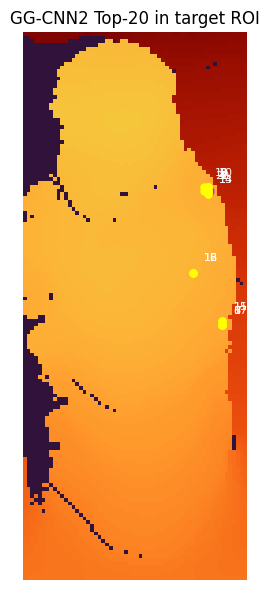

In [2]:
import json
import zipfile
import urllib.request
from pathlib import Path

import cv2
import numpy as np

try:
    import torch
    import torch.nn as nn
except Exception as e:
    raise RuntimeError(
        "PyTorch is required for GG-CNN2 inference. Install first, e.g. pip install torch"
    ) from e


class GGCNN2(nn.Module):
    def __init__(self, input_channels=1, filter_sizes=None, l3_k_size=5, dilations=None):
        super().__init__()
        if filter_sizes is None:
            filter_sizes = [16, 16, 32, 16]
        if dilations is None:
            dilations = [2, 4]

        self.features = nn.Sequential(
            nn.Conv2d(input_channels, filter_sizes[0], kernel_size=11, stride=1, padding=5, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(filter_sizes[0], filter_sizes[0], kernel_size=5, stride=1, padding=2, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(filter_sizes[0], filter_sizes[1], kernel_size=5, stride=1, padding=2, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(filter_sizes[1], filter_sizes[1], kernel_size=5, stride=1, padding=2, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(
                filter_sizes[1],
                filter_sizes[2],
                kernel_size=l3_k_size,
                dilation=dilations[0],
                stride=1,
                padding=(l3_k_size // 2 * dilations[0]),
                bias=True,
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                filter_sizes[2],
                filter_sizes[2],
                kernel_size=l3_k_size,
                dilation=dilations[1],
                stride=1,
                padding=(l3_k_size // 2 * dilations[1]),
                bias=True,
            ),
            nn.ReLU(inplace=True),
            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(filter_sizes[2], filter_sizes[3], 3, padding=1),
            nn.ReLU(inplace=True),
            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(filter_sizes[3], filter_sizes[3], 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.pos_output = nn.Conv2d(filter_sizes[3], 1, kernel_size=1)
        self.cos_output = nn.Conv2d(filter_sizes[3], 1, kernel_size=1)
        self.sin_output = nn.Conv2d(filter_sizes[3], 1, kernel_size=1)
        self.width_output = nn.Conv2d(filter_sizes[3], 1, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        return self.pos_output(x), self.cos_output(x), self.sin_output(x), self.width_output(x)


GGCNN_RELEASE_ZIP_URL = "https://github.com/dougsm/ggcnn/releases/download/v0.1/ggcnn2_weights_cornell.zip"
GGCNN_DIR = Path.cwd() / "models" / "ggcnn2_weights_cornell"
GGCNN_ZIP_PATH = Path.cwd() / "models" / "ggcnn2_weights_cornell.zip"
GGCNN_INPUT_SIZE = 300
TOPK_GRASP_CANDIDATES = 20

if "scene_objects" not in globals() or "depth_image" not in globals() or "intrinsics" not in globals():
    raise RuntimeError("Run cell 2 first to prepare scene_objects/depth_image/intrinsics.")

if not GGCNN_DIR.exists():
    GGCNN_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    if not GGCNN_ZIP_PATH.exists():
        print(f"Downloading GG-CNN2 weights: {GGCNN_RELEASE_ZIP_URL}")
        urllib.request.urlretrieve(GGCNN_RELEASE_ZIP_URL, GGCNN_ZIP_PATH)
    with zipfile.ZipFile(GGCNN_ZIP_PATH, "r") as zf:
        zf.extractall(GGCNN_ZIP_PATH.parent)

state_paths = sorted(GGCNN_DIR.glob("*_statedict.pt"))
if not state_paths:
    raise RuntimeError(f"Could not find GG-CNN2 state dict in {GGCNN_DIR}")

model = GGCNN2()
state = torch.load(state_paths[0], map_location="cpu")
model.load_state_dict(state)
model.eval()
print(f"Loaded GG-CNN2 state dict: {state_paths[0].name}")

# Use the currently selected target object index if available, else default to 0.
_target_idx = int(globals().get("TARGET_OBJECT_IDX", 0))
if _target_idx < 0 or _target_idx >= len(scene_objects):
    _target_idx = 0

target_for_ggcnn = scene_objects[_target_idx]
if target_for_ggcnn.get("center_xyz_mm") is None:
    raise RuntimeError("Selected target has no 3D center. Choose another object index.")

x1, y1, x2, y2 = [int(v) for v in target_for_ggcnn["bbox"]]
x1 = max(0, x1)
y1 = max(0, y1)
x2 = min(depth_image.shape[1], x2)
y2 = min(depth_image.shape[0], y2)
if x2 - x1 < 8 or y2 - y1 < 8:
    raise RuntimeError("Target bbox is too small for GG-CNN2 crop.")

depth_crop_mm = depth_image[y1:y2, x1:x2].astype(np.float32)
valid_crop = depth_crop_mm > 0
if np.count_nonzero(valid_crop) < 30:
    raise RuntimeError("Not enough valid depth pixels in target bbox for GG-CNN2.")

# Fill invalid depth with neighborhood interpolation for stable CNN input.
if np.any(~valid_crop):
    depth_fill = depth_crop_mm.copy()
    invalid = (depth_fill <= 0).astype(np.uint8)
    depth_fill = cv2.inpaint(depth_fill, invalid, 3, cv2.INPAINT_NS)
else:
    depth_fill = depth_crop_mm.copy()

median_d = float(np.median(depth_fill[depth_fill > 0]))
depth_norm = np.clip(depth_fill, median_d - 150.0, median_d + 150.0)
depth_norm = (depth_norm - median_d) / 150.0

in_h, in_w = depth_norm.shape
depth_nn = cv2.resize(depth_norm, (GGCNN_INPUT_SIZE, GGCNN_INPUT_SIZE), interpolation=cv2.INTER_LINEAR)
valid_nn = cv2.resize(valid_crop.astype(np.uint8), (GGCNN_INPUT_SIZE, GGCNN_INPUT_SIZE), interpolation=cv2.INTER_NEAREST).astype(bool)

with torch.no_grad():
    x = torch.from_numpy(depth_nn[None, None]).float()
    pos, cos, sin, width = model(x)

pos_map = pos.squeeze().cpu().numpy()
cos_map = cos.squeeze().cpu().numpy()
sin_map = sin.squeeze().cpu().numpy()
width_map = width.squeeze().cpu().numpy()

# Smooth quality map and suppress invalid pixels.
pos_map = cv2.GaussianBlur(pos_map, (5, 5), 0)
pos_map[~valid_nn] = -1e9


def nn_to_image_xy(px_n: int, py_n: int):
    px = int(round(x1 + (px_n + 0.5) * (in_w / GGCNN_INPUT_SIZE)))
    py = int(round(y1 + (py_n + 0.5) * (in_h / GGCNN_INPUT_SIZE)))
    px = int(np.clip(px, 0, depth_image.shape[1] - 1))
    py = int(np.clip(py, 0, depth_image.shape[0] - 1))
    return px, py


def resolve_valid_depth(px: int, py: int):
    z_mm = float(depth_image[py, px])
    if z_mm > 0:
        return px, py, z_mm

    ys, xs = np.where(depth_crop_mm > 0)
    if ys.size == 0:
        return px, py, 0.0

    d2 = (xs + x1 - px) ** 2 + (ys + y1 - py) ** 2
    k = int(np.argmin(d2))
    px2 = int(xs[k] + x1)
    py2 = int(ys[k] + y1)
    return px2, py2, float(depth_image[py2, px2])


valid_count = int(np.count_nonzero(valid_nn))
if valid_count <= 0:
    raise RuntimeError("No valid GG-CNN2 pixels after validity masking.")

topk = int(min(TOPK_GRASP_CANDIDATES, valid_count))
flat_scores = pos_map.reshape(-1)
flat_idx = np.argpartition(flat_scores, -topk)[-topk:]
flat_idx = flat_idx[np.argsort(flat_scores[flat_idx])[::-1]]

ggcnn_topk = []
for rank, fi in enumerate(flat_idx.tolist(), start=1):
    py_n, px_n = np.unravel_index(int(fi), pos_map.shape)
    px, py = nn_to_image_xy(int(px_n), int(py_n))
    px, py, z_mm = resolve_valid_depth(px, py)
    if z_mm <= 0:
        continue

    z_m = z_mm / 1000.0
    x_m = (float(px) - intrinsics.ppx) / intrinsics.fx * z_m
    y_m = (float(py) - intrinsics.ppy) / intrinsics.fy * z_m
    center_cam_mm = np.array([x_m * 1000.0, y_m * 1000.0, z_m * 1000.0], dtype=np.float32)
    center_task_mm = camera_to_task_frame(center_cam_mm).astype(np.float64)

    angle_rad = 0.5 * np.arctan2(float(sin_map[py_n, px_n]), float(cos_map[py_n, px_n]))
    angle_deg = float(np.degrees(angle_rad))
    width_mm = float(np.clip(width_map[py_n, px_n] * 150.0, 0.0, 120.0))
    quality = float(pos_map[py_n, px_n])

    ggcnn_topk.append(
        {
            "rank": int(rank),
            "pixel_xy": [int(px), int(py)],
            "quality": quality,
            "angle_rad": float(angle_rad),
            "angle_deg": float(angle_deg),
            "width_mm": float(width_mm),
            "center_camera_mm": [float(v) for v in center_cam_mm],
            "center_task_mm": [float(v) for v in center_task_mm],
        }
    )

if not ggcnn_topk:
    raise RuntimeError("Failed to build GG-CNN2 top-k candidates with valid depth.")

best = ggcnn_topk[0]
center_task_mm = np.asarray(best["center_task_mm"], dtype=np.float64)
angle_deg = float(best["angle_deg"])
width_mm = float(best["width_mm"])
quality = float(best["quality"])

ggcnn_grasp = {
    "target_object_idx": int(_target_idx),
    "pixel_xy": [int(best["pixel_xy"][0]), int(best["pixel_xy"][1])],
    "quality": quality,
    "angle_rad": float(best["angle_rad"]),
    "angle_deg": angle_deg,
    "width_mm": width_mm,
    "center_camera_mm": [float(v) for v in best["center_camera_mm"]],
    "center_task_mm": [float(v) for v in center_task_mm],
    "topk": ggcnn_topk,
}

print("GG-CNN2 grasp prediction (top-1 used for planning):")
print(json.dumps(ggcnn_grasp, indent=2, ensure_ascii=True))

if "plt" in globals():
    depth_vis_crop = cv2.normalize(depth_crop_mm, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    depth_vis_crop = cv2.applyColorMap(depth_vis_crop, cv2.COLORMAP_TURBO)
    fig_topk, ax_topk = plt.subplots(figsize=(7, 6))
    ax_topk.imshow(cv2.cvtColor(depth_vis_crop, cv2.COLOR_BGR2RGB))
    ax_topk.set_title(f"GG-CNN2 Top-{len(ggcnn_topk)} in target ROI")
    ax_topk.axis("off")

    for c in ggcnn_topk:
        px, py = int(c["pixel_xy"][0]), int(c["pixel_xy"][1])
        cx = px - x1
        cy = py - y1
        is_best = int(c["rank"]) == 1
        ax_topk.scatter([cx], [cy], s=60 if is_best else 26, c=["magenta" if is_best else "yellow"], marker="o")
        ax_topk.text(cx + 3, cy - 3, str(c["rank"]), color="white", fontsize=8)

    plt.tight_layout()
    plt.show()

# Interactive 3D grasp visualization on point cloud
if "go" in globals() and go is not None and "point_cloud_xyz_mm" in globals():
    gc = np.asarray(center_task_mm, dtype=np.float64)

    # Keep orientation consistent with final planning mapping: wrist_cmd = 90 - angle_deg
    grasp_yaw_deg = 90.0 - float(angle_deg)
    grasp_yaw_rad = np.deg2rad(grasp_yaw_deg)

    # Jaw axis in task XY plane, centered at predicted grasp point
    jaw_dir = np.array([np.cos(grasp_yaw_rad), np.sin(grasp_yaw_rad), 0.0], dtype=np.float64)
    jaw_half = max(5.0, float(width_mm) * 0.5)
    jaw_a = gc + jaw_half * jaw_dir
    jaw_b = gc - jaw_half * jaw_dir

    # Approach cue (upward marker for readability)
    up_len = 35.0
    up_tip = gc + np.array([0.0, 0.0, up_len], dtype=np.float64)

    traces_gg = []
    if point_cloud_xyz_mm.shape[0] > 0:
        n_show = min(12000, point_cloud_xyz_mm.shape[0])
        if point_cloud_xyz_mm.shape[0] > n_show:
            sel = np.random.choice(point_cloud_xyz_mm.shape[0], size=n_show, replace=False)
            cloud_xyz = point_cloud_xyz_mm[sel]
            cloud_rgb = point_cloud_rgb[sel]
        else:
            cloud_xyz = point_cloud_xyz_mm
            cloud_rgb = point_cloud_rgb

        traces_gg.append(
            go.Scatter3d(
                x=cloud_xyz[:, 0],
                y=cloud_xyz[:, 1],
                z=cloud_xyz[:, 2],
                mode="markers",
                marker={"size": 1, "color": cloud_rgb, "opacity": 0.28},
                name="raw cloud",
            )
        )

    for obj_idx, obj in enumerate(scene_objects):
        c = obj.get("center_xyz_mm")
        if c is None:
            continue
        color = obj.get("color_rgb_norm", (1.0, 0.0, 0.0))
        rgb = f"rgb({int(color[0]*255)},{int(color[1]*255)},{int(color[2]*255)})"
        is_target = obj_idx == int(_target_idx)
        traces_gg.append(
            go.Scatter3d(
                x=[float(c[0])],
                y=[float(c[1])],
                z=[float(c[2])],
                mode="markers+text",
                marker={"size": 9 if is_target else 6, "color": rgb},
                text=[f"[{obj_idx}] {obj['class_name']}" + (" (TARGET)" if is_target else "")],
                textposition="top center",
                name=f"obj [{obj_idx}]",
                showlegend=False,
            )
        )

    topk_centers = np.asarray([c["center_task_mm"] for c in ggcnn_topk], dtype=np.float64)
    topk_rank_text = [str(c["rank"]) for c in ggcnn_topk]
    traces_gg.append(
        go.Scatter3d(
            x=topk_centers[:, 0],
            y=topk_centers[:, 1],
            z=topk_centers[:, 2],
            mode="markers+text",
            marker={"size": 5, "color": "rgb(255,255,0)", "opacity": 0.9},
            text=topk_rank_text,
            textposition="top center",
            name=f"GG-CNN2 Top-{len(ggcnn_topk)}",
        )
    )

    traces_gg.append(
        go.Scatter3d(
            x=[float(gc[0])],
            y=[float(gc[1])],
            z=[float(gc[2])],
            mode="markers+text",
            marker={"size": 9, "color": "rgb(255,0,255)", "symbol": "diamond"},
            text=["GG-CNN2 grasp center (top-1)"],
            textposition="top center",
            name="grasp center",
        )
    )
    traces_gg.append(
        go.Scatter3d(
            x=[float(jaw_a[0]), float(jaw_b[0])],
            y=[float(jaw_a[1]), float(jaw_b[1])],
            z=[float(jaw_a[2]), float(jaw_b[2])],
            mode="lines+markers",
            line={"width": 10, "color": "rgb(255,0,255)"},
            marker={"size": 4, "color": "rgb(255,0,255)"},
            name="predicted jaw axis/width",
        )
    )
    traces_gg.append(
        go.Scatter3d(
            x=[float(gc[0]), float(up_tip[0])],
            y=[float(gc[1]), float(up_tip[1])],
            z=[float(gc[2]), float(up_tip[2])],
            mode="lines",
            line={"width": 5, "color": "rgb(255,150,0)"},
            name="grasp marker",
        )
    )

    fig_gg = go.Figure(data=traces_gg)
    fig_gg.update_layout(
        title=(
            f"GG-CNN2 Predicted Grasp on 3D Cloud"
            f"<br>obj=[{_target_idx}] {target_for_ggcnn['class_name']}, "
            f"q={quality:.3f}, angle={angle_deg:.1f}deg, width={width_mm:.1f}mm, topk={len(ggcnn_topk)}"
        ),
        scene={
            "xaxis_title": "X (forward, mm)",
            "yaxis_title": "Y (left, mm)",
            "zaxis_title": "Z (up, mm)",
        },
        height=820,
    )
    fig_gg.show()
else:
    print("GG-CNN2 3D visualization skipped: plotly or point cloud is unavailable.")

In [3]:
import json
import time
import numpy as np

from robot_arm_servo_model import HOME_DEG, SERVO_MIN, SERVO_MAX, LINKS_M, fk_servo, solve_servo_from_target

# Select target object by index in scene_objects list (0-based)
TARGET_OBJECT_IDX = 0
USE_GGCNN_GRASP = True

# Show mode: keep only final robot pose in the 3D view
SHOW_ONLY_FINAL_POSE = True

# Planning mode: "fast" | "balanced" | "accurate"
PLANNING_MODE = "fast"

# Planning / safety parameters
APPROACH_OFFSET_MM = 120.0
APPROACH_OFFSET_CANDIDATES_MM = [120.0, 160.0, 220.0]
TCP_MATCH_TOL_MM = 8.0
ARM_LINK_RADIUS_MM = 14.0
MAX_FINAL_TARGET_OFFSET_MM = 45.0

# Hard safety constraint against the full point cloud
HARD_MIN_CLEARANCE_MM = 10.0
COLLISION_MARGIN_MM = HARD_MIN_CLEARANCE_MM
TARGET_EXCLUSION_RADIUS_MM = None
REQUIRE_FEASIBLE_PLAN = True

# CBF-like safety shaping
CBF_ALPHA = 2.0
CBF_EPS_MM = 1e-3

# Candidate TCP sampling around detected target (orientation ignored)
AUTO_FIND_COLLISION_FREE_TCP = True
TOPK_GRASP_FOR_PLANNING = 20

# Render optimization
RENDER_POINT_STRIDE = 2
RENDER_MAX_POINTS = 3500
RENDER_RANDOM_PICK = True

MODE_CONFIG = {
    "fast": {
        "MAX_OBSTACLE_POINTS": 3000,
        "PATH_INTERP_STEPS": 8,
        "CANDIDATE_XY_RADII_MM": [0.0, 20.0, 50.0, 90.0],
        "CANDIDATE_Z_OFFSETS_MM": [-10.0, 0.0, 20.0, 60.0, 100.0],
        "CANDIDATE_ANGLE_SAMPLES": 8,
    },
    "balanced": {
        "MAX_OBSTACLE_POINTS": 6000,
        "PATH_INTERP_STEPS": 14,
        "CANDIDATE_XY_RADII_MM": [0.0, 20.0, 50.0, 90.0, 140.0],
        "CANDIDATE_Z_OFFSETS_MM": [-20.0, 0.0, 20.0, 50.0, 90.0, 130.0],
        "CANDIDATE_ANGLE_SAMPLES": 12,
    },
    "accurate": {
        "MAX_OBSTACLE_POINTS": 12000,
        "PATH_INTERP_STEPS": 24,
        "CANDIDATE_XY_RADII_MM": [0.0, 20.0, 40.0, 60.0, 80.0, 110.0, 140.0, 170.0, 200.0],
        "CANDIDATE_Z_OFFSETS_MM": [-40.0, -20.0, 0.0, 20.0, 40.0, 80.0, 120.0],
        "CANDIDATE_ANGLE_SAMPLES": 24,
    },
}

if PLANNING_MODE not in MODE_CONFIG:
    raise ValueError(f"Unknown PLANNING_MODE={PLANNING_MODE}. Use one of {list(MODE_CONFIG.keys())}.")

MAX_OBSTACLE_POINTS = int(MODE_CONFIG[PLANNING_MODE]["MAX_OBSTACLE_POINTS"])
PATH_INTERP_STEPS = int(MODE_CONFIG[PLANNING_MODE]["PATH_INTERP_STEPS"])
CANDIDATE_XY_RADII_MM = list(MODE_CONFIG[PLANNING_MODE]["CANDIDATE_XY_RADII_MM"])
CANDIDATE_Z_OFFSETS_MM = list(MODE_CONFIG[PLANNING_MODE]["CANDIDATE_Z_OFFSETS_MM"])
CANDIDATE_ANGLE_SAMPLES = int(MODE_CONFIG[PLANNING_MODE]["CANDIDATE_ANGLE_SAMPLES"])
APPROACH_OFFSET_CANDIDATES_MM = [float(v) for v in APPROACH_OFFSET_CANDIDATES_MM]

JOINT_MIN_DEG = np.asarray(SERVO_MIN, dtype=np.float64)
JOINT_MAX_DEG = np.asarray(SERVO_MAX, dtype=np.float64)

# Reachability bounds for aggressive point pruning
SHOULDER_ORIGIN_MM = np.asarray(ROBOT_BASE_MM, dtype=np.float64) + np.array([0.0, 0.0, float(LINKS_M[0] * 1000.0)], dtype=np.float64)
ARM_MAX_REACH_MM = float((LINKS_M[1] + LINKS_M[2] + LINKS_M[3] + LINKS_M[4]) * 1000.0)
OBSTACLE_KEEP_RADIUS_MM = ARM_MAX_REACH_MM + ARM_LINK_RADIUS_MM + HARD_MIN_CLEARANCE_MM + 20.0

if "scene_objects" not in globals():
    raise RuntimeError("Run cell 2 first to build scene_objects.")
if "point_cloud_xyz_mm" not in globals() or "point_cloud_rgb" not in globals():
    raise RuntimeError("Run cell 2 first to build point_cloud_xyz_mm and point_cloud_rgb.")

if USE_GGCNN_GRASP and "ggcnn_grasp" in globals():
    TARGET_OBJECT_IDX = int(ggcnn_grasp.get("target_object_idx", TARGET_OBJECT_IDX))

print("Available objects in task frame (X=forward, Y=left, Z=up):")
for idx, obj in enumerate(scene_objects):
    if obj["center_xyz_mm"] is not None:
        center = obj["center_xyz_mm"]
        print(f"  [{idx}] {obj['class_name']} (score={obj['score']:.3f}, pos=({center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f})mm)")
    else:
        print(f"  [{idx}] {obj['class_name']} (score={obj['score']:.3f}, 3D=unavailable)")

print("\nJoint limits (deg):")
for j in range(6):
    print(f"  joint[{j}] min={JOINT_MIN_DEG[j]:.1f}, max={JOINT_MAX_DEG[j]:.1f}")

print("\nPlanner mode:")
print(f"  mode={PLANNING_MODE}")
print(f"  max_obstacle_points={MAX_OBSTACLE_POINTS}, path_interp_steps={PATH_INTERP_STEPS}")
print(f"  candidate_radii={CANDIDATE_XY_RADII_MM}")
print(f"  candidate_z_offsets={CANDIDATE_Z_OFFSETS_MM}, angle_samples={CANDIDATE_ANGLE_SAMPLES}")
print(f"  approach_offset_candidates={APPROACH_OFFSET_CANDIDATES_MM}")

if TARGET_OBJECT_IDX < 0 or TARGET_OBJECT_IDX >= len(scene_objects):
    raise ValueError(
        f"TARGET_OBJECT_IDX={TARGET_OBJECT_IDX} out of range. Available indices: 0-{len(scene_objects)-1}"
    )

target_obj = scene_objects[TARGET_OBJECT_IDX]
if target_obj["center_xyz_mm"] is None:
    raise ValueError(
        f"Selected object at index {TARGET_OBJECT_IDX} ({target_obj['class_name']}) does not have valid 3D position."
    )


def grasp_angle_to_wrist_deg(angle_deg: float) -> float:
    return float(np.clip(90.0 - angle_deg, JOINT_MIN_DEG[4], JOINT_MAX_DEG[4]))


def width_mm_to_gripper_deg(width_mm: float) -> float:
    w = float(np.clip(width_mm, 0.0, 100.0))
    return float(np.clip(180.0 * (1.0 - w / 100.0), JOINT_MIN_DEG[5], JOINT_MAX_DEG[5]))


def subsample_for_render(points_mm: np.ndarray, colors_rgb: np.ndarray):
    if points_mm.size == 0:
        return points_mm, colors_rgb
    idx = np.arange(points_mm.shape[0], dtype=np.int64)
    if RENDER_POINT_STRIDE > 1:
        idx = idx[:: int(RENDER_POINT_STRIDE)]
    if idx.size > RENDER_MAX_POINTS:
        if RENDER_RANDOM_PICK:
            idx = np.random.choice(idx, size=RENDER_MAX_POINTS, replace=False)
        else:
            idx = idx[:RENDER_MAX_POINTS]
    return points_mm[idx], colors_rgb[idx]


def is_tcp_candidate_reachable(candidate_tcp_mm: np.ndarray) -> bool:
    rel = np.asarray(candidate_tcp_mm, dtype=np.float64) - np.asarray(ROBOT_BASE_MM, dtype=np.float64)
    r_xy = float(np.hypot(rel[0], rel[1]))
    z_from_shoulder = float(rel[2] - LINKS_M[0] * 1000.0)
    d = float(np.hypot(r_xy, z_from_shoulder))
    return d <= (ARM_MAX_REACH_MM + 5.0)


def build_grasp_candidates():
    if USE_GGCNN_GRASP:
        if "ggcnn_grasp" not in globals():
            raise RuntimeError("Run the previous GG-CNN2 grasp prediction cell first.")
        topk = ggcnn_grasp.get("topk") or []
        if not topk:
            topk = [{
                "rank": 1,
                "pixel_xy": ggcnn_grasp["pixel_xy"],
                "quality": ggcnn_grasp["quality"],
                "angle_deg": ggcnn_grasp.get("angle_deg", 0.0),
                "width_mm": ggcnn_grasp.get("width_mm", 45.0),
                "center_task_mm": ggcnn_grasp["center_task_mm"],
            }]
        out = []
        for item in topk[: int(min(TOPK_GRASP_FOR_PLANNING, len(topk)))]:
            out.append({
                "rank": int(item.get("rank", len(out) + 1)),
                "point_mm": np.asarray(item["center_task_mm"], dtype=np.float64),
                "angle_deg": float(item.get("angle_deg", 0.0)),
                "width_mm": float(item.get("width_mm", 45.0)),
                "quality": float(item.get("quality", 0.0)),
                "pixel_xy": list(item.get("pixel_xy", [-1, -1])),
            })
        return out

    return [{
        "rank": 1,
        "point_mm": target_obj["center_xyz_mm"].astype(np.float64).copy(),
        "angle_deg": 0.0,
        "width_mm": 45.0,
        "quality": 0.0,
        "pixel_xy": [-1, -1],
    }]


def compute_target_exclusion_radius_mm(target_item: dict, grasp_candidates: list[dict]) -> float:
    size_xyz = target_item.get("size_xyz_mm")
    if size_xyz is not None:
        half_extent = 0.5 * float(np.max(np.asarray(size_xyz, dtype=np.float64)))
    else:
        half_extent = 20.0
    width_based = max(float(c["width_mm"]) for c in grasp_candidates) * 0.35 if grasp_candidates else 15.0
    return max(12.0, min(70.0, half_extent * 0.8 + width_based))


grasp_candidates = build_grasp_candidates()
primary_grasp = grasp_candidates[0]

if TARGET_EXCLUSION_RADIUS_MM is None:
    TARGET_EXCLUSION_RADIUS_MM = compute_target_exclusion_radius_mm(target_obj, grasp_candidates)

grasp_point_mm = np.asarray(primary_grasp["point_mm"], dtype=np.float64)
ggcnn_angle_deg = float(primary_grasp["angle_deg"])
ggcnn_width_mm = float(primary_grasp["width_mm"])

grasp_wrist_deg = grasp_angle_to_wrist_deg(ggcnn_angle_deg)
grasp_gripper_deg = width_mm_to_gripper_deg(ggcnn_width_mm)
approach_gripper_deg = width_mm_to_gripper_deg(min(100.0, ggcnn_width_mm + 20.0))

print("\nUsing primary grasp target:")
print(f"  point_mm=({grasp_point_mm[0]:.1f}, {grasp_point_mm[1]:.1f}, {grasp_point_mm[2]:.1f})")
print(f"  ggcnn_angle_deg={ggcnn_angle_deg:.2f}, wrist_cmd_deg={grasp_wrist_deg:.2f}")
print(f"  ggcnn_width_mm={ggcnn_width_mm:.2f}, gripper_cmd_deg={grasp_gripper_deg:.2f}")
print(f"  planning_grasp_candidates={len(grasp_candidates)}")
print(f"  auto target exclusion radius={TARGET_EXCLUSION_RADIUS_MM:.1f} mm")


def _eval_tcp(servo_deg: np.ndarray, base_mm: np.ndarray):
    pts_m, fingers_m = fk_servo(servo_deg, base_mm)
    tcp_mm = pts_m[-1] * 1000.0
    return tcp_mm, pts_m, fingers_m


def solve_servo_with_tcp_match(desired_tcp_mm: np.ndarray, base_mm: np.ndarray):
    desired = np.asarray(desired_tcp_mm, dtype=np.float64)
    servo = solve_servo_from_target(desired, base_mm).astype(np.float64)
    servo = np.clip(servo, JOINT_MIN_DEG, JOINT_MAX_DEG)
    servo[5] = JOINT_MAX_DEG[5]

    best_tcp, best_pts_m, best_fingers_m = _eval_tcp(servo, base_mm)
    best_err_vec = desired - best_tcp
    best_err = float(np.linalg.norm(best_err_vec))

    eval_count = 1
    step_schedule = [10.0, 5.0, 2.0, 1.0] if PLANNING_MODE == "fast" else [14.0, 8.0, 4.0, 2.0, 1.0, 0.5]
    for step in step_schedule:
        improved = True
        while improved:
            improved = False
            for j in [0, 1, 2, 3, 4]:
                for delta in (-step, step):
                    cand = servo.copy()
                    cand[j] = float(np.clip(cand[j] + delta, JOINT_MIN_DEG[j], JOINT_MAX_DEG[j]))
                    cand[5] = JOINT_MAX_DEG[5]
                    tcp_mm, pts_m, fingers_m = _eval_tcp(cand, base_mm)
                    eval_count += 1
                    err_vec = desired - tcp_mm
                    err = float(np.linalg.norm(err_vec))
                    if err + 1e-9 < best_err:
                        servo = cand
                        best_tcp = tcp_mm
                        best_pts_m = pts_m
                        best_fingers_m = fingers_m
                        best_err_vec = err_vec
                        best_err = err
                        improved = True
                        if best_err <= TCP_MATCH_TOL_MM:
                            return {
                                "evals": eval_count,
                                "servo_deg": servo,
                                "pts_m": best_pts_m,
                                "fingers_m": best_fingers_m,
                                "tcp_mm": best_tcp,
                                "err_vec_mm": best_err_vec,
                                "err_norm_mm": best_err,
                            }
    return {
        "evals": eval_count,
        "servo_deg": servo,
        "pts_m": best_pts_m,
        "fingers_m": best_fingers_m,
        "tcp_mm": best_tcp,
        "err_vec_mm": best_err_vec,
        "err_norm_mm": best_err,
    }


def point_to_segment_distance_mm(points_mm: np.ndarray, a_mm: np.ndarray, b_mm: np.ndarray) -> np.ndarray:
    ab = b_mm - a_mm
    denom = float(np.dot(ab, ab)) + 1e-9
    t = np.clip(((points_mm - a_mm) @ ab) / denom, 0.0, 1.0)
    proj = a_mm + t[:, None] * ab[None, :]
    return np.linalg.norm(points_mm - proj, axis=1)


def arm_min_clearance_mm(arm_pts_mm: np.ndarray, obstacle_cloud_mm: np.ndarray, link_radius_mm: float) -> float:
    if obstacle_cloud_mm.size == 0:
        return float("inf")
    min_dist = float("inf")
    for i in range(arm_pts_mm.shape[0] - 1):
        d = point_to_segment_distance_mm(obstacle_cloud_mm, arm_pts_mm[i], arm_pts_mm[i + 1])
        min_dist = min(min_dist, float(np.min(d)))
    return min_dist - float(link_radius_mm)


def build_obstacle_cloud(scene_cloud_mm: np.ndarray, target_center_mm: np.ndarray, exclusion_r_mm: float, max_points: int):
    if scene_cloud_mm.size == 0:
        return np.zeros((0, 3), dtype=np.float64), {"in": 0, "after_reach": 0, "after_target_exclusion": 0, "after_cap": 0}
    cloud = np.asarray(scene_cloud_mm, dtype=np.float64)
    stats = {"in": int(cloud.shape[0])}
    d_shoulder = np.linalg.norm(cloud - SHOULDER_ORIGIN_MM[None, :], axis=1)
    cloud = cloud[d_shoulder <= OBSTACLE_KEEP_RADIUS_MM]
    stats["after_reach"] = int(cloud.shape[0])
    if exclusion_r_mm > 0.0 and cloud.shape[0] > 0:
        d_target = np.linalg.norm(cloud - target_center_mm[None, :], axis=1)
        cloud = cloud[d_target > exclusion_r_mm]
    stats["after_target_exclusion"] = int(cloud.shape[0])
    if cloud.shape[0] > max_points:
        keep = np.random.choice(cloud.shape[0], size=max_points, replace=False)
        cloud = cloud[keep]
    stats["after_cap"] = int(cloud.shape[0])
    return cloud, stats


def generate_tcp_candidates(center_mm: np.ndarray):
    cands = []
    for r in CANDIDATE_XY_RADII_MM:
        if r == 0:
            for dz in CANDIDATE_Z_OFFSETS_MM:
                p = center_mm + np.array([0.0, 0.0, dz], dtype=np.float64)
                if is_tcp_candidate_reachable(p):
                    cands.append(p)
            continue
        for k in range(CANDIDATE_ANGLE_SAMPLES):
            ang = 2.0 * np.pi * k / CANDIDATE_ANGLE_SAMPLES
            dx = r * np.cos(ang)
            dy = r * np.sin(ang)
            for dz in CANDIDATE_Z_OFFSETS_MM:
                p = center_mm + np.array([dx, dy, dz], dtype=np.float64)
                if is_tcp_candidate_reachable(p):
                    cands.append(p)
    uniq = []
    for p in cands:
        if not uniq:
            uniq.append(p)
            continue
        if np.min([np.linalg.norm(p - q) for q in uniq]) > 1e-3:
            uniq.append(p)
    return uniq


def estimate_total_candidate_count() -> int:
    count = 0
    for r in CANDIDATE_XY_RADII_MM:
        mul = 1 if float(r) == 0.0 else CANDIDATE_ANGLE_SAMPLES
        count += mul * len(CANDIDATE_Z_OFFSETS_MM)
    return int(count)


def interpolate_servo_path(start_deg: np.ndarray, end_deg: np.ndarray, steps: int):
    t = np.linspace(0.0, 1.0, int(steps), dtype=np.float64)
    return [((1.0 - x) * start_deg + x * end_deg) for x in t]


def path_clearance_and_cbf(servo_path: list[np.ndarray], obstacle_cloud_mm: np.ndarray):
    if obstacle_cloud_mm.size == 0:
        return float("inf"), 0.0
    path_min_clear = float("inf")
    barrier_cost = 0.0
    for q in servo_path:
        _, pts_m, _ = _eval_tcp(q, ROBOT_BASE_MM)
        clear = arm_min_clearance_mm(pts_m * 1000.0, obstacle_cloud_mm, ARM_LINK_RADIUS_MM)
        path_min_clear = min(path_min_clear, clear)
        h = clear - HARD_MIN_CLEARANCE_MM
        barrier_cost += CBF_ALPHA / max(h, CBF_EPS_MM)
    return path_min_clear, float(barrier_cost)


def apply_grasp_orientation_and_width(sol: dict, wrist_deg: float, grip_deg: float, desired_tcp_mm: np.ndarray):
    q = np.asarray(sol["servo_deg"], dtype=np.float64).copy()
    q[4] = float(np.clip(wrist_deg, JOINT_MIN_DEG[4], JOINT_MAX_DEG[4]))
    q[5] = float(np.clip(grip_deg, JOINT_MIN_DEG[5], JOINT_MAX_DEG[5]))
    tcp_mm, pts_m, fingers_m = _eval_tcp(q, ROBOT_BASE_MM)
    err_vec = np.asarray(desired_tcp_mm, dtype=np.float64) - tcp_mm
    err_norm = float(np.linalg.norm(err_vec))
    new_sol = dict(sol)
    new_sol["servo_deg"] = q
    new_sol["tcp_mm"] = tcp_mm
    new_sol["pts_m"] = pts_m
    new_sol["fingers_m"] = fingers_m
    new_sol["err_vec_mm"] = err_vec
    new_sol["err_norm_mm"] = err_norm
    return new_sol


def evaluate_candidate_tcp(candidate_grasp_tcp_mm: np.ndarray, target_center_mm: np.ndarray, obstacle_cloud_mm: np.ndarray, wrist_deg: float, approach_grip_deg: float, grasp_grip_deg: float, grasp_meta: dict, approach_offset_mm: float):
    candidate_approach_tcp_mm = candidate_grasp_tcp_mm + np.array([0.0, 0.0, approach_offset_mm], dtype=np.float64)
    approach_sol = solve_servo_with_tcp_match(candidate_approach_tcp_mm, ROBOT_BASE_MM)
    grasp_sol = solve_servo_with_tcp_match(candidate_grasp_tcp_mm, ROBOT_BASE_MM)
    if USE_GGCNN_GRASP:
        approach_sol = apply_grasp_orientation_and_width(approach_sol, wrist_deg, approach_grip_deg, candidate_approach_tcp_mm)
        grasp_sol = apply_grasp_orientation_and_width(grasp_sol, wrist_deg, grasp_grip_deg, candidate_grasp_tcp_mm)
    approach_pts_mm = approach_sol["pts_m"] * 1000.0
    grasp_pts_mm = grasp_sol["pts_m"] * 1000.0
    clear_approach = arm_min_clearance_mm(approach_pts_mm, obstacle_cloud_mm, ARM_LINK_RADIUS_MM)
    clear_grasp = arm_min_clearance_mm(grasp_pts_mm, obstacle_cloud_mm, ARM_LINK_RADIUS_MM)
    seg1 = interpolate_servo_path(np.asarray(HOME_DEG, dtype=np.float64), approach_sol["servo_deg"], PATH_INTERP_STEPS)
    seg2 = interpolate_servo_path(approach_sol["servo_deg"], grasp_sol["servo_deg"], PATH_INTERP_STEPS)
    path_min_seg1, cbf_seg1 = path_clearance_and_cbf(seg1, obstacle_cloud_mm)
    path_min_seg2, cbf_seg2 = path_clearance_and_cbf(seg2, obstacle_cloud_mm)
    min_clear = float(min(clear_approach, clear_grasp, path_min_seg1, path_min_seg2))
    cbf_cost = float(cbf_seg1 + cbf_seg2)
    dist_to_target = float(np.linalg.norm(candidate_grasp_tcp_mm - target_center_mm))
    final_target_offset = float(np.linalg.norm(grasp_sol["tcp_mm"] - target_center_mm))
    tcp_fit_cost = float(approach_sol["err_norm_mm"] + grasp_sol["err_norm_mm"])
    feasible = (min_clear >= HARD_MIN_CLEARANCE_MM) and (final_target_offset <= MAX_FINAL_TARGET_OFFSET_MM)
    score = (
        0 if feasible else 1,
        final_target_offset,
        dist_to_target,
        max(HARD_MIN_CLEARANCE_MM - min_clear, 0.0),
        tcp_fit_cost,
        cbf_cost,
        -min_clear,
        -float(grasp_meta.get("quality", 0.0)),
        int(grasp_meta.get("rank", 9999)),
        float(approach_offset_mm),
    )
    return {
        "score": score,
        "feasible": feasible,
        "min_clear_mm": min_clear,
        "dist_to_target_mm": dist_to_target,
        "final_target_offset_mm": final_target_offset,
        "cbf_cost": cbf_cost,
        "approach_solution": approach_sol,
        "grasp_solution": grasp_sol,
        "approach_tcp_mm": approach_sol["tcp_mm"],
        "grasp_tcp_mm": grasp_sol["tcp_mm"],
        "desired_grasp_tcp_mm": candidate_grasp_tcp_mm,
        "desired_approach_tcp_mm": candidate_approach_tcp_mm,
        "grasp_meta": grasp_meta,
        "approach_offset_mm": float(approach_offset_mm),
    }


obstacle_t0 = time.perf_counter()
obstacle_cloud_mm, obstacle_stats = build_obstacle_cloud(point_cloud_xyz_mm, grasp_point_mm, exclusion_r_mm=TARGET_EXCLUSION_RADIUS_MM, max_points=MAX_OBSTACLE_POINTS)
obstacle_t1 = time.perf_counter()

candidate_total_nominal = estimate_total_candidate_count()
all_plans = []
reachable_candidates_per_grasp = []

cand_t0 = time.perf_counter()
for grasp_meta in grasp_candidates:
    local_point_mm = np.asarray(grasp_meta["point_mm"], dtype=np.float64)
    local_angle_deg = float(grasp_meta["angle_deg"])
    local_width_mm = float(grasp_meta["width_mm"])
    local_wrist_deg = grasp_angle_to_wrist_deg(local_angle_deg)
    local_grasp_gripper_deg = width_mm_to_gripper_deg(local_width_mm)
    local_approach_gripper_deg = width_mm_to_gripper_deg(min(100.0, local_width_mm + 20.0))
    tcp_candidates = generate_tcp_candidates(local_point_mm) if AUTO_FIND_COLLISION_FREE_TCP else [local_point_mm]
    reachable_candidates_per_grasp.append(int(len(tcp_candidates)))
    for cand in tcp_candidates:
        for approach_offset_mm in APPROACH_OFFSET_CANDIDATES_MM:
            all_plans.append((grasp_meta, cand, local_point_mm, local_wrist_deg, local_approach_gripper_deg, local_grasp_gripper_deg, float(approach_offset_mm)))
cand_t1 = time.perf_counter()

eval_t0 = time.perf_counter()
feasible_plans = []
best_any_plan = None
for grasp_meta, cand, target_center_mm, wrist_deg, approach_grip_deg, grasp_grip_deg, approach_offset_mm in all_plans:
    plan = evaluate_candidate_tcp(cand, target_center_mm, obstacle_cloud_mm, wrist_deg, approach_grip_deg, grasp_grip_deg, grasp_meta, approach_offset_mm)
    if best_any_plan is None or plan["score"] < best_any_plan["score"]:
        best_any_plan = plan
    if plan["feasible"]:
        feasible_plans.append(plan)
eval_t1 = time.perf_counter()

if feasible_plans:
    best_plan = min(feasible_plans, key=lambda p: p["score"])
else:
    best_plan = best_any_plan

if REQUIRE_FEASIBLE_PLAN and (not best_plan["feasible"]):
    raise RuntimeError(
        "No trajectory satisfies clearance/target-offset constraints. "
        f"best_min_clear={best_plan['min_clear_mm']:.2f} mm, best_final_target_offset={best_plan['final_target_offset_mm']:.2f} mm. "
        "Try increasing APPROACH_OFFSET_CANDIDATES_MM, relaxing MAX_FINAL_TARGET_OFFSET_MM, or reducing point-cloud noise."
    )

best_grasp_meta = best_plan["grasp_meta"]
selected_rank = int(best_grasp_meta.get("rank", 1))
selected_pixel_xy = list(best_grasp_meta.get("pixel_xy", [-1, -1]))
selected_quality = float(best_grasp_meta.get("quality", 0.0))
selected_target_center_mm = np.asarray(best_grasp_meta["point_mm"], dtype=np.float64)
selected_angle_deg = float(best_grasp_meta["angle_deg"])
selected_width_mm = float(best_grasp_meta["width_mm"])
selected_wrist_deg = grasp_angle_to_wrist_deg(selected_angle_deg)
selected_gripper_deg = width_mm_to_gripper_deg(selected_width_mm)
selected_approach_offset_mm = float(best_plan["approach_offset_mm"])

approach_solution = best_plan["approach_solution"]
grasp_solution = best_plan["grasp_solution"]
approach_deg = approach_solution["servo_deg"]
grasp_deg = grasp_solution["servo_deg"]
final_pts_mm = grasp_solution["pts_m"] * 1000.0
final_fingers_mm = grasp_solution["fingers_m"] * 1000.0
final_tcp_mm = grasp_solution["tcp_mm"]

print("\nCollision-aware TCP planning report")
print(f"  obstacle points used: {obstacle_cloud_mm.shape[0]}")
print(f"  obstacle pruning stats: {obstacle_stats}")
print(f"  target exclusion radius: {TARGET_EXCLUSION_RADIUS_MM:.1f} mm")
print(f"  hard min clearance: {HARD_MIN_CLEARANCE_MM:.1f} mm")
print(f"  max final target offset: {MAX_FINAL_TARGET_OFFSET_MM:.1f} mm")
print(f"  feasible collision-free plan: {best_plan['feasible']}")
print(f"  selected ggcnn rank: {selected_rank} (quality={selected_quality:.3f}, pixel={selected_pixel_xy})")
print(f"  selected grasp angle/width: {selected_angle_deg:.2f} deg / {selected_width_mm:.2f} mm")
print(f"  selected approach offset: {selected_approach_offset_mm:.1f} mm")
print(f"  min arm clearance (whole path): {best_plan['min_clear_mm']:.2f} mm")
print(f"  cbf-like barrier cost: {best_plan['cbf_cost']:.2f}")
print(f"  desired grasp point to selected target center: {best_plan['dist_to_target_mm']:.2f} mm")
print(f"  final tcp distance from selected target center: {best_plan['final_target_offset_mm']:.2f} mm")
print(f"  final tcp fit error after wrist/gripper apply: {grasp_solution['err_norm_mm']:.2f} mm (evals={grasp_solution['evals']})")
print(f"  candidate count (nominal per grasp): {candidate_total_nominal}")
print(f"  candidate count (reachable total): {sum(reachable_candidates_per_grasp)} x {len(APPROACH_OFFSET_CANDIDATES_MM)} approach offsets across {len(grasp_candidates)} grasp candidates")
print(f"  timing: obstacle={1000.0*(obstacle_t1-obstacle_t0):.1f}ms, candidate_gen={1000.0*(cand_t1-cand_t0):.1f}ms, evaluate={1000.0*(eval_t1-eval_t0):.1f}ms")

traces_grip = []
if point_cloud_xyz_mm.shape[0] > 0:
    cloud_xyz, cloud_rgb = subsample_for_render(point_cloud_xyz_mm, point_cloud_rgb)
    traces_grip.append(go.Scatter3d(x=cloud_xyz[:, 0], y=cloud_xyz[:, 1], z=cloud_xyz[:, 2], mode="markers", marker={"size": 1, "color": cloud_rgb, "opacity": 0.35}, name="raw cloud"))

for obj_idx, obj in enumerate(scene_objects):
    center = obj["center_xyz_mm"]
    if center is None:
        continue
    color = obj.get("color_rgb_norm", (1.0, 0.0, 0.0))
    is_target = obj is target_obj
    rgb_str = f"rgb({int(color[0]*255)},{int(color[1]*255)},{int(color[2]*255)})"
    traces_grip.append(go.Scatter3d(x=[float(center[0])], y=[float(center[1])], z=[float(center[2])], mode="markers+text", marker={"size": 10 if is_target else 7, "color": rgb_str, "line": {"color": "white", "width": 2} if is_target else {}}, text=[f"[{obj_idx}] {obj['class_name']} (TARGET)" if is_target else f"[{obj_idx}] {obj['class_name']}"] , textposition="top center", name=f"[{obj_idx}] {obj['class_name']}" + (" (TARGET)" if is_target else "")))

if USE_GGCNN_GRASP and "ggcnn_grasp" in globals():
    all_topk = ggcnn_grasp.get("topk") or []
    if all_topk:
        topk_centers = np.asarray([c["center_task_mm"] for c in all_topk[:TOPK_GRASP_FOR_PLANNING]], dtype=np.float64)
        topk_rank_text = [str(c.get("rank", i + 1)) for i, c in enumerate(all_topk[:TOPK_GRASP_FOR_PLANNING])]
        traces_grip.append(go.Scatter3d(x=topk_centers[:, 0], y=topk_centers[:, 1], z=topk_centers[:, 2], mode="markers+text", marker={"size": 4, "color": "rgb(255,255,0)", "opacity": 0.7}, text=topk_rank_text, textposition="top center", name=f"GG-CNN2 Top-{len(topk_rank_text)}"))
    traces_grip.append(go.Scatter3d(x=[float(selected_target_center_mm[0])], y=[float(selected_target_center_mm[1])], z=[float(selected_target_center_mm[2])], mode="markers+text", marker={"size": 10, "color": "rgb(255,0,255)", "symbol": "diamond"}, text=[f"selected ggcnn rank {selected_rank}"], textposition="top center", name="Selected GG-CNN2 Grasp"))

traces_grip.append(go.Scatter3d(x=final_pts_mm[:, 0], y=final_pts_mm[:, 1], z=final_pts_mm[:, 2], mode="lines+markers+text", line={"color": "rgb(20,190,120)", "width": 7}, marker={"size": 4, "color": "rgb(20,190,120)"}, text=["base", "j1", "j2", "j3", "tool", "tcp"], textposition="top center", name="Final Arm Pose"))
traces_grip.append(go.Scatter3d(x=final_fingers_mm[:, 0], y=final_fingers_mm[:, 1], z=final_fingers_mm[:, 2], mode="lines+markers", line={"color": "rgb(20,190,120)", "width": 9}, marker={"size": 3, "color": "rgb(20,190,120)"}, name="Final Gripper"))
traces_grip.append(go.Scatter3d(x=[float(final_tcp_mm[0])], y=[float(final_tcp_mm[1])], z=[float(final_tcp_mm[2])], mode="markers+text", marker={"size": 8, "color": "rgb(255,60,60)", "symbol": "x"}, text=["final tcp"], textposition="top center", name="Final TCP"))

fig_grip = go.Figure(data=traces_grip)
fig_grip.update_layout(title=(f"Final Robot Pose Only for '[{TARGET_OBJECT_IDX}] {target_obj['class_name']}'" f"<br>selected_rank={selected_rank}, approach={selected_approach_offset_mm:.0f}mm, clearance={best_plan['min_clear_mm']:.1f}mm, final_offset={best_plan['final_target_offset_mm']:.1f}mm"), scene={"xaxis_title": "X (forward, mm)", "yaxis_title": "Y (left, mm)", "zaxis_title": "Z (up, mm)"}, height=850)
fig_grip.show()

grip_plan = {
    "device_target": DEVICE_TARGET,
    "task_frame": {"origin": "camera", "x_axis": "forward", "y_axis": "left", "z_axis": "up"},
    "target_object_idx": TARGET_OBJECT_IDX,
    "target_object_class": target_obj["class_name"],
    "ggcnn_grasp": ggcnn_grasp if (USE_GGCNN_GRASP and "ggcnn_grasp" in globals()) else None,
    "selected_grasp": {
        "rank": int(selected_rank),
        "pixel_xy": selected_pixel_xy,
        "quality": float(selected_quality),
        "angle_deg": float(selected_angle_deg),
        "width_mm": float(selected_width_mm),
        "center_task_mm": [float(v) for v in selected_target_center_mm],
        "wrist_cmd_deg": float(selected_wrist_deg),
        "gripper_cmd_deg": float(selected_gripper_deg),
        "approach_offset_mm": float(selected_approach_offset_mm),
    },
    "joint_limits_deg": {"min": [float(v) for v in JOINT_MIN_DEG], "max": [float(v) for v in JOINT_MAX_DEG]},
    "planning": {
        "mode": PLANNING_MODE,
        "auto_find_collision_free_tcp": bool(AUTO_FIND_COLLISION_FREE_TCP),
        "collision_free_found": bool(best_plan["feasible"]),
        "obstacle_points_used": int(obstacle_cloud_mm.shape[0]),
        "obstacle_pruning_stats": obstacle_stats,
        "candidate_count_nominal_per_grasp": int(candidate_total_nominal),
        "grasp_candidates_evaluated": int(len(grasp_candidates)),
        "approach_offset_candidates_mm": [float(v) for v in APPROACH_OFFSET_CANDIDATES_MM],
        "candidate_count_reachable_total": int(sum(reachable_candidates_per_grasp) * len(APPROACH_OFFSET_CANDIDATES_MM)),
        "arm_link_radius_mm": float(ARM_LINK_RADIUS_MM),
        "hard_min_clearance_mm": float(HARD_MIN_CLEARANCE_MM),
        "target_exclusion_radius_mm": float(TARGET_EXCLUSION_RADIUS_MM),
        "max_final_target_offset_mm": float(MAX_FINAL_TARGET_OFFSET_MM),
        "cbf_alpha": float(CBF_ALPHA),
        "cbf_cost": float(best_plan["cbf_cost"]),
        "desired_grasp_to_target_mm": float(best_plan['dist_to_target_mm']),
        "final_tcp_distance_from_target_mm": float(best_plan['final_target_offset_mm']),
        "min_arm_clearance_mm": float(best_plan['min_clear_mm']),
        "timing_ms": {
            "obstacle_build": float(1000.0 * (obstacle_t1 - obstacle_t0)),
            "candidate_generation": float(1000.0 * (cand_t1 - cand_t0)),
            "candidate_evaluation": float(1000.0 * (eval_t1 - eval_t0)),
        },
    },
    "final_tcp_mm": [float(v) for v in final_tcp_mm],
    "final_servo_deg": [float(v) for v in grasp_deg],
    "servo_plan_deg": {"home": [float(v) for v in HOME_DEG], "approach": [float(v) for v in approach_deg], "grasp": [float(v) for v in grasp_deg]},
}

print(json.dumps(grip_plan, indent=2, ensure_ascii=True))

Available objects in task frame (X=forward, Y=left, Z=up):
  [0] bottle (score=0.854, pos=(349.0, 50.4, -459.2)mm)
  [1] keyboard (score=0.794, pos=(383.6, -205.8, -529.8)mm)
  [2] bottle (score=0.667, pos=(946.8, -203.6, -483.4)mm)
  [3] cup (score=0.485, pos=(875.3, 87.2, -550.6)mm)
  [4] remote (score=0.417, pos=(558.1, -116.0, -495.9)mm)

Joint limits (deg):
  joint[0] min=0.0, max=180.0
  joint[1] min=0.0, max=180.0
  joint[2] min=0.0, max=180.0
  joint[3] min=0.0, max=180.0
  joint[4] min=0.0, max=180.0
  joint[5] min=0.0, max=180.0

Planner mode:
  mode=fast
  max_obstacle_points=3000, path_interp_steps=8
  candidate_radii=[0.0, 20.0, 50.0, 90.0]
  candidate_z_offsets=[-10.0, 0.0, 20.0, 60.0, 100.0], angle_samples=8
  approach_offset_candidates=[120.0, 160.0, 220.0]

Using primary grasp target:
  point_mm=(364.7, 29.9, -420.2)
  ggcnn_angle_deg=85.58, wrist_cmd_deg=4.42
  ggcnn_width_mm=120.00, gripper_cmd_deg=0.00
  planning_grasp_candidates=20
  auto target exclusion radius=70

{
  "device_target": "raspi",
  "task_frame": {
    "origin": "camera",
    "x_axis": "forward",
    "y_axis": "left",
    "z_axis": "up"
  },
  "target_object_idx": 0,
  "target_object_class": "bottle",
  "ggcnn_grasp": {
    "target_object_idx": 0,
    "pixel_xy": [
      286,
      282
    ],
    "quality": 1.587408185005188,
    "angle_rad": 1.493726982728208,
    "angle_deg": 85.58425185513714,
    "width_mm": 120.0,
    "center_camera_mm": [
      -29.883745193481445,
      39.2362060546875,
      555.0
    ],
    "center_task_mm": [
      364.7000732421875,
      29.883745193481445,
      -420.18841552734375
    ],
    "topk": [
      {
        "rank": 1,
        "pixel_xy": [
          286,
          282
        ],
        "quality": 1.587408185005188,
        "angle_rad": 1.493726982728208,
        "angle_deg": 85.58425185513714,
        "width_mm": 120.0,
        "center_camera_mm": [
          -29.883745193481445,
          39.2362060546875,
          555.0
        ],
      

In [4]:
import importlib
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

if "grip_plan" not in globals():
    raise RuntimeError("Run the final planning cell first to build grip_plan.")
if rs is None:
    raise RuntimeError(
        "Live RealSense capture requires a working pyrealsense2 install. "
        f"Import error: {RS_IMPORT_ERROR}"
    )

ARM_INSTALL_DIR = Path.cwd() / "0.py_install"
if not ARM_INSTALL_DIR.exists():
    raise RuntimeError(f"Arm control directory not found: {ARM_INSTALL_DIR}")
if str(ARM_INSTALL_DIR) not in sys.path:
    sys.path.insert(0, str(ARM_INSTALL_DIR))

Arm_Device = importlib.import_module("Arm_Lib").Arm_Device

ARM_MOVE_HOME_FIRST = True
ARM_RETURN_HOME_AFTER = False
ARM_RGB_BEFORE = (0, 0, 40)
ARM_RGB_MOVING = (40, 20, 0)
ARM_RGB_AFTER = (0, 40, 0)
ARM_MOVE_MS = 1800
ARM_SETTLE_S = 1.5
REAL_SENSE_WARMUP_FRAMES = 12


def capture_live_rgbd_frame():
    pipeline = rs.pipeline()
    config = rs.config()
    config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
    config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
    align = rs.align(rs.stream.color)

    pipeline.start(config)
    try:
        for _ in range(REAL_SENSE_WARMUP_FRAMES):
            pipeline.wait_for_frames()
        frames = align.process(pipeline.wait_for_frames())
        depth_frame = frames.get_depth_frame()
        color_frame = frames.get_color_frame()
        if not depth_frame or not color_frame:
            raise RuntimeError("Could not get synchronized RGB-D frame from RealSense.")
        depth_image = np.asanyarray(depth_frame.get_data()).astype(np.uint16)
        color_image = np.asanyarray(color_frame.get_data())
    finally:
        pipeline.stop()
    return color_image, depth_image


def show_before_after_rgbd(before_color_bgr, before_depth_mm, after_color_bgr, after_depth_mm):
    before_depth_vis = cv2.applyColorMap(cv2.convertScaleAbs(before_depth_mm, alpha=0.03), cv2.COLORMAP_JET)
    after_depth_vis = cv2.applyColorMap(cv2.convertScaleAbs(after_depth_mm, alpha=0.03), cv2.COLORMAP_JET)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes[0, 0].set_title("Before Move: RGB")
    axes[0, 0].imshow(cv2.cvtColor(before_color_bgr, cv2.COLOR_BGR2RGB))
    axes[0, 0].axis("off")

    axes[0, 1].set_title("Before Move: Depth")
    axes[0, 1].imshow(cv2.cvtColor(before_depth_vis, cv2.COLOR_BGR2RGB))
    axes[0, 1].axis("off")

    axes[1, 0].set_title("After Move: RGB")
    axes[1, 0].imshow(cv2.cvtColor(after_color_bgr, cv2.COLOR_BGR2RGB))
    axes[1, 0].axis("off")

    axes[1, 1].set_title("After Move: Depth")
    axes[1, 1].imshow(cv2.cvtColor(after_depth_vis, cv2.COLOR_BGR2RGB))
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def clip_servo_targets(joints_deg):
    joints = np.asarray(joints_deg, dtype=np.float64).copy()
    if joints.shape != (6,):
        raise ValueError(f"Expected 6 servo values, got shape={joints.shape}")

    limits = grip_plan.get("joint_limits_deg") or {}
    mins = np.asarray(limits.get("min", [0, 0, 0, 0, 0, 0]), dtype=np.float64)
    maxs = np.asarray(limits.get("max", [180, 180, 180, 180, 270, 180]), dtype=np.float64)
    joints = np.clip(joints, mins, maxs)
    return [int(round(v)) for v in joints.tolist()]


def move_arm_sequence(arm, joint_sequence_deg, move_ms=ARM_MOVE_MS, settle_s=ARM_SETTLE_S):
    for step_idx, joints_deg in enumerate(joint_sequence_deg, start=1):
        safe_joints = clip_servo_targets(joints_deg)
        print(f"Move step {step_idx}: joints={safe_joints}, time_ms={move_ms}")
        arm.Arm_serial_servo_write6_array(safe_joints, int(move_ms))
        time.sleep(float(move_ms) / 1000.0 + float(settle_s))


before_color_image, before_depth_image = capture_live_rgbd_frame()
print("Captured live RGB-D before robot motion.")

servo_plan = grip_plan.get("servo_plan_deg") or {}
home_deg = servo_plan.get("home", HOME_DEG)
approach_deg = servo_plan.get("approach")
grasp_deg = servo_plan.get("grasp")
if approach_deg is None or grasp_deg is None:
    raise RuntimeError("grip_plan['servo_plan_deg'] must include both 'approach' and 'grasp'.")

joint_sequence = []
if ARM_MOVE_HOME_FIRST:
    joint_sequence.append(home_deg)
joint_sequence.extend([approach_deg, grasp_deg])
if ARM_RETURN_HOME_AFTER:
    joint_sequence.append(home_deg)

arm = None
try:
    arm = Arm_Device()
    time.sleep(0.2)
    arm.Arm_RGB_set(*ARM_RGB_BEFORE)
    time.sleep(0.2)
    arm.Arm_RGB_set(*ARM_RGB_MOVING)
    move_arm_sequence(arm, joint_sequence)
    arm.Arm_RGB_set(*ARM_RGB_AFTER)

    readback = []
    for servo_id in range(1, 7):
        readback.append(arm.Arm_serial_servo_read(servo_id))
    print(f"Servo readback after motion: {readback}")
finally:
    if arm is not None:
        try:
            del arm
        except Exception:
            pass

after_color_image, after_depth_image = capture_live_rgbd_frame()
print("Captured live RGB-D after robot motion.")

show_before_after_rgbd(
    before_color_image,
    before_depth_image,
    after_color_image,
    after_depth_image,
    )

ModuleNotFoundError: No module named 'smbus'